In [1]:
import sys
import os

# _miqp_dir  = uavsafeplanning/MIQP/   (MIQP_MINCO_solver etc.)
# _parent_dir = uavsafeplanning/        (traj_gen_utils package)
_miqp_dir   = os.path.abspath("")
_parent_dir = os.path.dirname(_miqp_dir)

for _p in [_miqp_dir, _parent_dir]:
    if _p not in sys.path:
        sys.path.insert(0, _p)

# Change working directory to uavsafeplanning/ so that relative file paths
# like "traj_gen_utils/data/forest.txt" resolve correctly.
os.chdir(_parent_dir)

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from traj_gen_utils import MINCO_S3NU

from traj_gen_utils import load_voxel_grid
import pyvista as pv
pv.set_jupyter_backend('html')

# load voxel grid environment
path = "traj_gen_utils/data/forest.txt"
vg = load_voxel_grid(path, padding=0)
vg.plot_pyvista()
grid3D = vg.grid

from traj_gen_utils import astar_3d, visualize

start = (1, 5, 10)
goal = (90, 90, 10)
start_grid_idx = vg.info.to_index(start)
goal_grid_idx = vg.info.to_index(goal)

path_indices = astar_3d(grid3D, start_grid_idx, goal_grid_idx, connectivity=18)
visualize(vg, path_indices)

import pydecomp as pdc
from traj_gen_utils import visualize_voxelgrid_with_path
from traj_gen_utils import reduce_turns_by_los

# prune path to only keep straight line segments
path = reduce_turns_by_los(np.array(path_indices), grid3D)

origin    = np.asarray(vg.info.origin, dtype=np.float64)
occ_idx   = np.argwhere(vg.grid == 1)
obs_np    = (occ_idx + 0.5).astype(np.float64) + origin
path_np   = (np.asarray(path, np.float64) + 0.5) + origin 
box_np    = np.array([[5.0, 5.0, 5.0]], dtype=np.float64)

A_list, b_list = pdc.convex_decomposition_3D(obs_np, path_np, box_np)
# (A_list, b_list) is a list of half-space representations of convex polytopes

visualize_voxelgrid_with_path(vg, path_indices, A_list=A_list, b_list=b_list)


EmbeddableWidget(value='<iframe srcdoc="<!DOCTYPE html>\n<html>\n  <head>\n    <meta http-equiv=&quot;Content-…

EmbeddableWidget(value='<iframe srcdoc="<!DOCTYPE html>\n<html>\n  <head>\n    <meta http-equiv=&quot;Content-…

[viz] surf points/cells: 128248 128848
[viz] surf bounds: BoundsTuple(x_min =   0.0,
            x_max = 100.0,
            y_min =   0.0,
            y_max = 100.0,
            z_min =   0.0,
            z_max =  40.0)
[viz] centers min/max: [ 1.5  5.5 10.5] [91.5 90.5 10.5]
[viz] segments: 5


EmbeddableWidget(value='<iframe srcdoc="<!DOCTYPE html>\n<html>\n  <head>\n    <meta http-equiv=&quot;Content-…

In [2]:
##########################################
### STEP 1: Environment Setup (Continued)
##########################################

print("="*60)
print("ENVIRONMENT SETUP - COMMON PARAMETERS")
print("="*60)

# Number of corridors (from convex decomposition)
n_corridors = len(A_list)
print(f"\n[1] Safe Flight Corridors: {n_corridors} corridors")
for i, (A, b) in enumerate(zip(A_list, b_list)):
    print(f"    Corridor {i}: {A.shape[0]} half-space constraints")

# Number of segments (MUST BE SAME FOR BOTH METHODS)
n_segments = n_corridors  # N = 5 segments
print(f"\n[2] Trajectory Segmentation: N = {n_segments} segments")

# Waypoints from A* path
waypoints_init = path_np[1:-1]  # Exclude start and goal
n_waypoints = len(waypoints_init)
print(f"    Intermediate waypoints: {n_waypoints} (N-1)")
print(f"    Start point: [{path_np[0][0]:.2f}, {path_np[0][1]:.2f}, {path_np[0][2]:.2f}]")
for i, wp in enumerate(waypoints_init):
    print(f"    Waypoint {i}: [{wp[0]:.2f}, {wp[1]:.2f}, {wp[2]:.2f}]")
print(f"    Goal point:  [{path_np[-1][0]:.2f}, {path_np[-1][1]:.2f}, {path_np[-1][2]:.2f}]")

# Boundary Conditions (SAME FOR BOTH METHODS)
pos_init = path_np[0]       # Start position
vel_init = np.array([0.0, 0.0, 0.0])   # Start velocity
acc_init = np.array([0.0, 0.0, 0.0])   # Start acceleration

pos_final = path_np[-1]     # Goal position
vel_final = np.array([0.0, 0.0, 0.0])  # Goal velocity
acc_final = np.array([0.0, 0.0, 0.0])  # Goal acceleration

print(f"\n[3] Boundary Conditions:")
print(f"    Initial: P={pos_init}, V={vel_init}, A={acc_init}")
print(f"    Final:   P={pos_final}, V={vel_final}, A={acc_final}")

# Dynamic Limits (SAME FOR BOTH METHODS)
v_max = 2.0   # m/s - maximum velocity
a_max = 1.0   # m/s² - maximum acceleration


print(f"\n[4] Dynamic Limits:")
print(f"    Max velocity:     v_max = {v_max} m/s")
print(f"    Max acceleration: a_max = {a_max} m/s²")
print(f"    Jerk: unconstrained (minimized as objective)")

# Calculate segment lengths (for time initialization)
segment_lengths = []
segment_lengths.append(np.linalg.norm(waypoints_init[0] - path_np[0]))  # start to wp0
for i in range(len(waypoints_init) - 1):
    segment_lengths.append(np.linalg.norm(waypoints_init[i+1] - waypoints_init[i]))
segment_lengths.append(np.linalg.norm(path_np[-1] - waypoints_init[-1]))  # last wp to goal

total_path_length = sum(segment_lengths)

print(f"\n[5] Path Statistics:")
print(f"    Total path length: {total_path_length:.2f} m")
print(f"    Segment lengths: {[f'{l:.2f}' for l in segment_lengths]}")

# Initial time allocation (heuristic based on segment length and max velocity)
time_init = [length / v_max for length in segment_lengths]
total_time_init = sum(time_init)

print(f"    Initial time allocation: {[f'{t:.2f}s' for t in time_init]}")
print(f"    Total initial time: {total_time_init:.2f} s")

print("\n" + "="*60)
print("✓ Environment setup complete!")
print("="*60)

ENVIRONMENT SETUP - COMMON PARAMETERS

[1] Safe Flight Corridors: 5 corridors
    Corridor 0: 14 half-space constraints
    Corridor 1: 10 half-space constraints
    Corridor 2: 8 half-space constraints
    Corridor 3: 10 half-space constraints
    Corridor 4: 8 half-space constraints

[2] Trajectory Segmentation: N = 5 segments
    Intermediate waypoints: 4 (N-1)
    Start point: [1.50, 5.50, 10.50]
    Waypoint 0: [23.50, 24.50, 10.50]
    Waypoint 1: [61.50, 60.50, 10.50]
    Waypoint 2: [64.50, 61.50, 10.50]
    Waypoint 3: [91.50, 88.50, 10.50]
    Goal point:  [90.50, 90.50, 10.50]

[3] Boundary Conditions:
    Initial: P=[ 1.5  5.5 10.5], V=[0. 0. 0.], A=[0. 0. 0.]
    Final:   P=[90.5 90.5 10.5], V=[0. 0. 0.], A=[0. 0. 0.]

[4] Dynamic Limits:
    Max velocity:     v_max = 2.0 m/s
    Max acceleration: a_max = 1.0 m/s²
    Jerk: unconstrained (minimized as objective)

[5] Path Statistics:
    Total path length: 125.00 m
    Segment lengths: ['29.07', '52.35', '3.16', '38.18', '

In [3]:
##########################################
### STEP 2: STO — L1 / L2 / Log Corridor Cost Comparison
##########################################

from sto_cost_comparison_planner import STOPlanner

# ── Per-method hyperparameters ─────────────────────────────────────────────
# Weights are tuned per cost function because L1/L2/Log operate on different
# magnitude scales and gradient regimes.
#
# L2 (quadratic): standard baseline — large violations are aggressively penalised
# L1 (linear):    constant gradient → needs much higher lambda to compete with jerk
# Log (log1p):    smooth, between L1 and L2 for large violations — fine-tune vel

# ── Adaptive weight settings ──────────────────────────────────────────────
# When True: constraint weights start at lambda/scale^(phases-1) and are
# multiplied by scale_factor at each phase boundary. L-BFGS is reset at
# every transition so the Hessian approximation stays consistent.
USE_ADAPTIVE    = True   # ← toggle here
WEIGHT_PHASES   = 3
WEIGHT_SCALE    = 5.0

BASE = dict(
    n_segments=n_segments,
    A_list=A_list,
    b_list=b_list,
    waypoints_init=waypoints_init,
    time_init=time_init,
    v_max=v_max,
    a_max=a_max,
    learn_rate=0.05,
    max_iter=50,
    verbose=True,
    adaptive_weights=USE_ADAPTIVE,
    weight_phases=WEIGHT_PHASES,
    weight_scale_factor=WEIGHT_SCALE,
)

PARAMS = {
    # ── L2 — previous run proved these work well ───────────────────────────
    'L2': dict(
        lambda_jerk=10.0,
        lambda_time=0.05,
        lambda_vel=120.0,
        lambda_acc=5.0,
        lambda_corridor=1000.0,
        corridor_cost_type='l2',
    ),
    # ── L1 — linear gradient needs 5-8× higher corridor & vel weights ──────
    'L1': dict(
        lambda_jerk=10.0,
        lambda_time=0.05,
        lambda_vel=120.0,
        lambda_acc=5.0,
        lambda_corridor=1900.0,
        corridor_cost_type='l1',
    ),
    # ── Log — worked at L2 weights; nudge vel weight to fix 0.064 violation ─
    'Log': dict(
        lambda_jerk=10.0,
        lambda_time=0.01,
        lambda_vel=120.0,
        lambda_acc=5.0,
        lambda_corridor=1200.0,
        corridor_cost_type='log',
    ),
}

SOLVE = dict(
    pos_init=pos_init, vel_init=vel_init, acc_init=acc_init,
    pos_final=pos_final, vel_final=vel_final, acc_final=acc_final,
)

# ── Run all three methods ──────────────────────────────────────────────────
METHODS = ['L2', 'L1', 'Log']
results_all = {}

for m in METHODS:
    print(f"\n{'='*60}")
    print(f"  STO  |  corridor cost: {m}")
    print('='*60)
    planner = STOPlanner(**BASE, **PARAMS[m])
    planner.solve(**SOLVE)
    results_all[m] = planner.get_results(n_samples=200)
    r = results_all[m]
    print(f"\n✓ {m}: runtime={r['runtime']:.2f}s | "
          f"jerk={r['jerk_cost']:.4f} | T={r['total_time']:.2f}s")

print("\n" + "="*60)
print("✓ All three methods complete!")
print("="*60)


  STO  |  corridor cost: L2


/home/okanarif/repositories/CopySemesterThesis/uavsafeplanning/STO_Cost_Comparison/sto_cost_comparison_planner.py:146: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  self.waypoints = torch.tensor([waypoints_init], dtype=torch.float32, requires_grad=True)


STO TRAJECTORY OPTIMIZATION
Segments:       5
Waypoints:      4
Max iterations: 50
Corridor cost:  L2 penalty
Adaptive weights: ON  (3 phases, ×5.0 per phase)

Objective weights (fixed):
  λ_jerk     = 10.00
  λ_time     = 0.05

Constraint weights (phase 1 / final target):
  λ_vel      = 4.80  →  120.00
  λ_acc      = 0.20  →  5.00
  λ_corridor = 40.00  →  1000.00  [L2]

Iter | Phase |        Total |       Jerk |     Time |        Vel |        Acc |       Corr
--------------------------------------------------------------------------------------------------
   1 |     1 |  1190.372192 |   2.888332 |    56.38 |   1.271696 |   0.035113 |  28.813972
   5 |     1 |     4.013885 |   0.018544 |    73.10 |   0.036179 |   0.000000 |   0.000000
  10 |     1 |     3.993179 |   0.015915 |    73.63 |   0.031196 |   0.000000 |   0.000069
  15 |     1 |     3.993179 |   0.015915 |    73.63 |   0.031196 |   0.000000 |   0.000069

  ── Phase 2/3: λ_vel=24.0  λ_acc=1.0  λ_corridor=200.0  (L-BFGS reset)

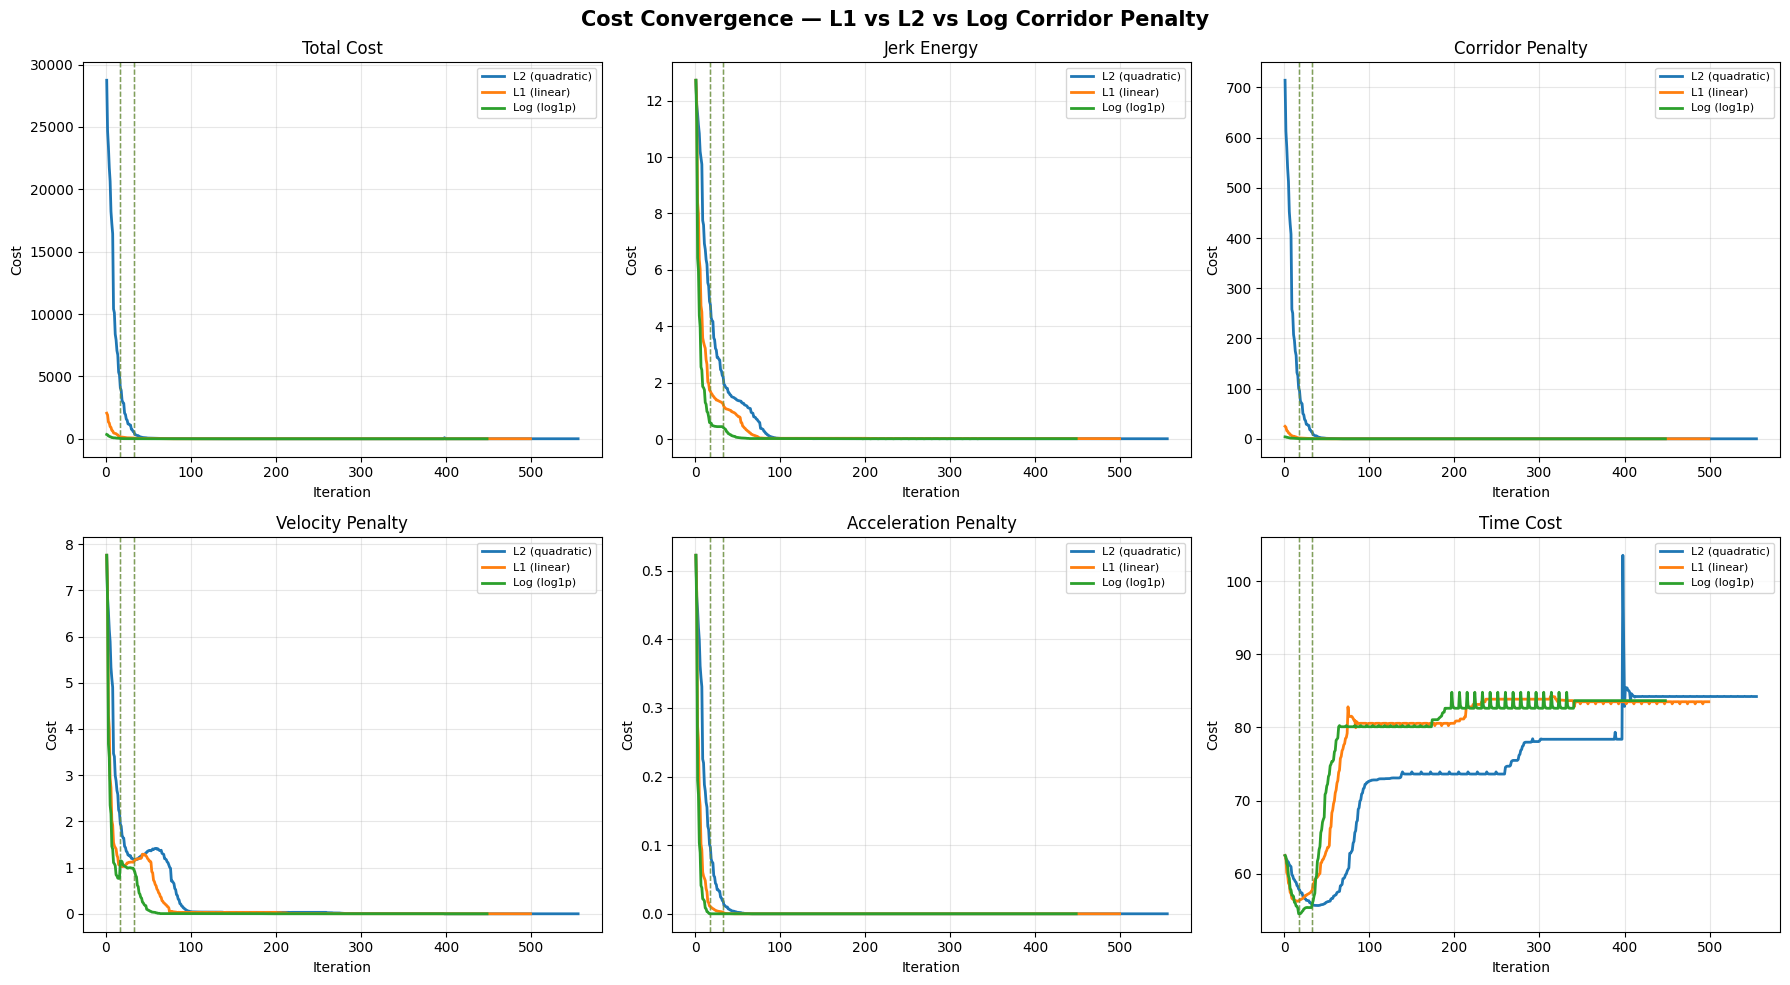

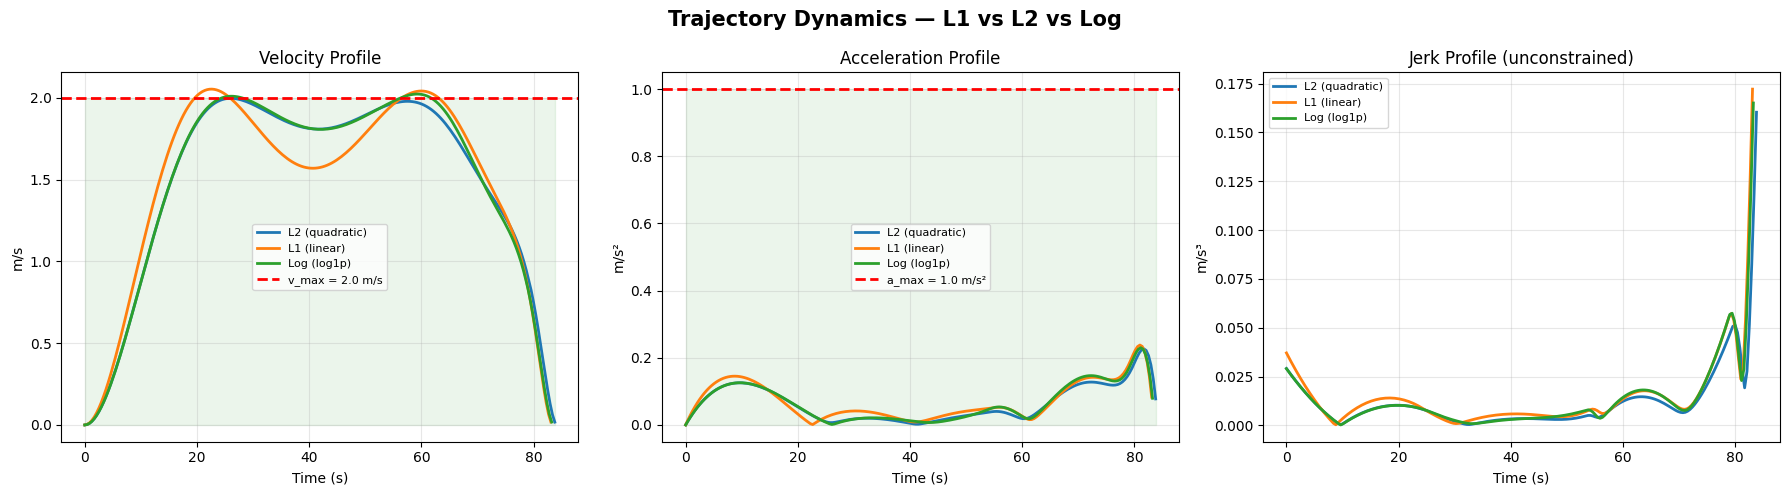

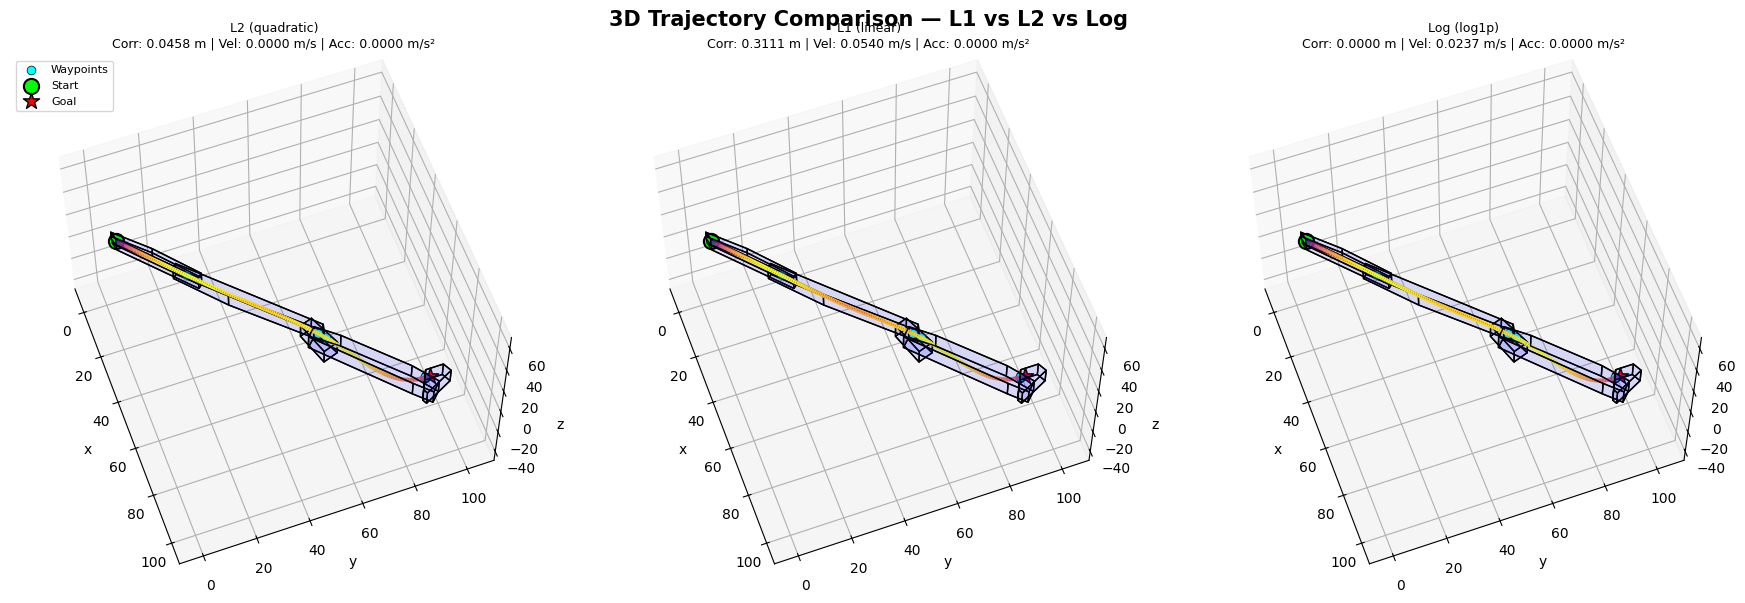

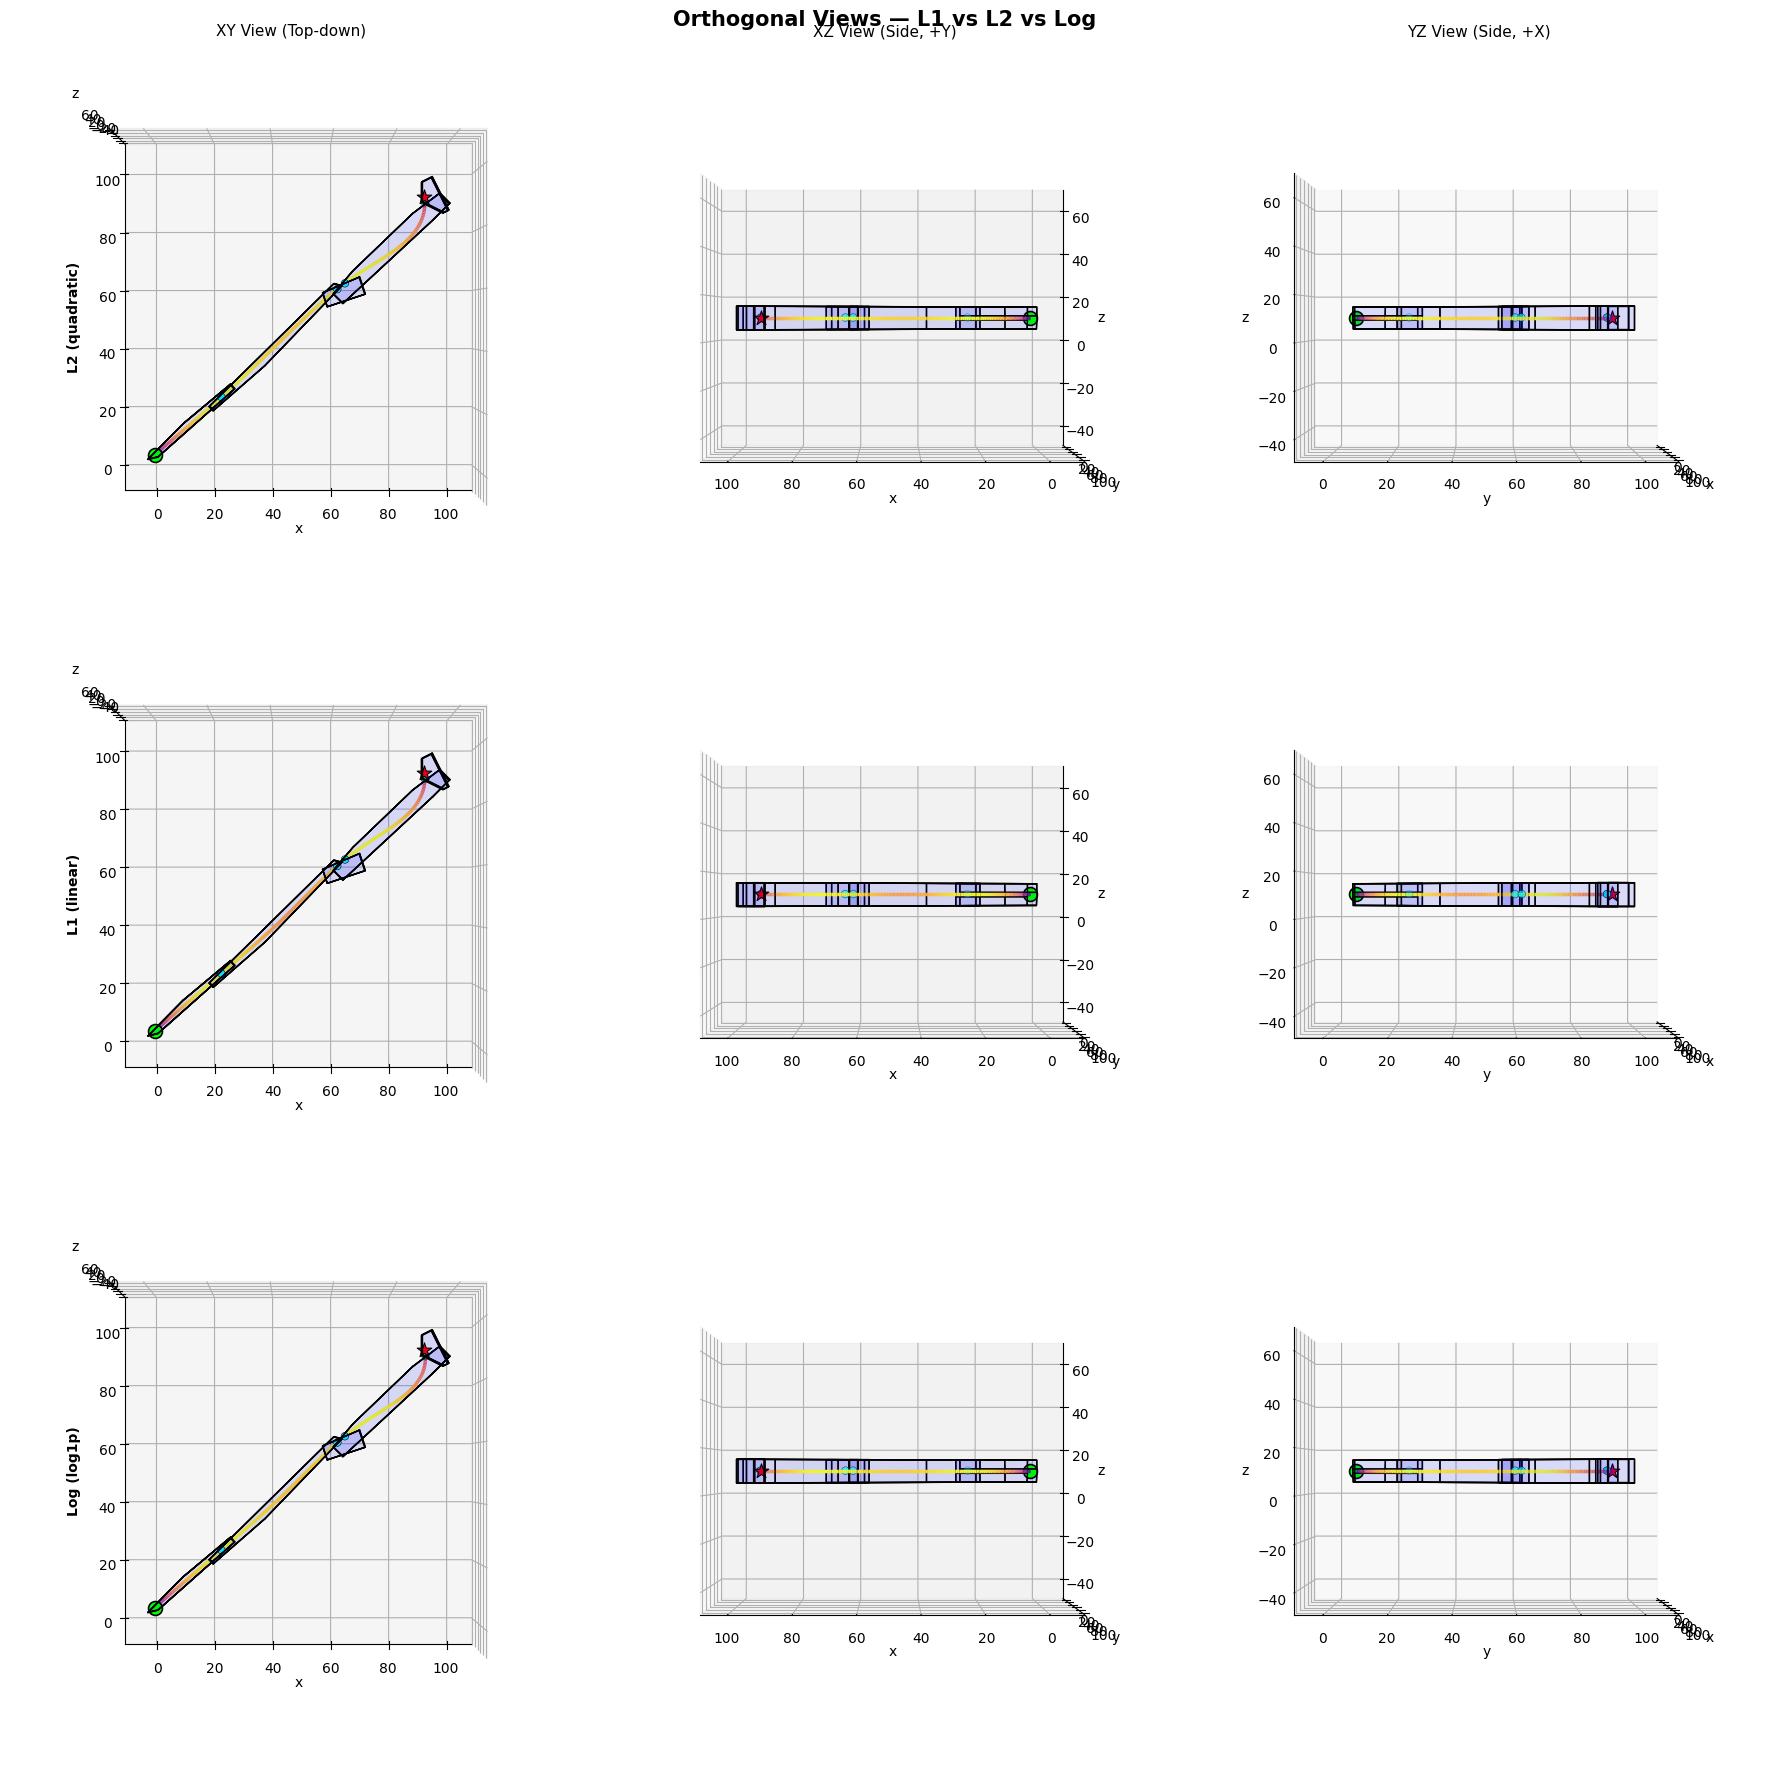


  CORRIDOR COST FUNCTION COMPARISON SUMMARY
Method               | Runtime (s) |   Jerk Cost | Total T (s) | Vel Viol (m/s) | Acc Viol (m/s²) | Corr Viol (m)
-----------------------------------------------------------------------------------------------
L2 (quadratic)       |       9.224 |    0.012197 |      84.220 |     0.000000 ✓ |      0.000000 ✓ |    0.045755 ✗
L1 (linear)          |       7.298 |    0.016305 |      83.507 |     0.053979 ✗ |      0.000000 ✓ |    0.311096 ✗
Log (log1p)          |       7.158 |    0.014189 |      83.660 |     0.023731 ✗ |      0.000000 ✓ |    0.000000 ✓

Legend:  ✓ = no significant violation (<1e-4)  |  ✗ = violation detected
Corridor violation = max(Ax − b) sampled at 200 points along the trajectory.
Vel / Acc violation = max(norm − limit) across 200 sample points.


In [4]:
##########################################
### STEP 3: Comparison Visualization + Table
##########################################

import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Line3DCollection
import pydecomp as pdc

COLORS  = {'L2': 'C0', 'L1': 'C1', 'Log': 'C2'}
LABELS  = {'L2': 'L2 (quadratic)', 'L1': 'L1 (linear)', 'Log': 'Log (log1p)'}

# ══════════════════════════════════════════════════════════════════════════════
# Figure 1 — Cost convergence (2 × 3)
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Cost Convergence — L1 vs L2 vs Log Corridor Penalty", fontsize=15, fontweight='bold')

cost_panels = [
    ('total',    'Total Cost'),
    ('jerk',     'Jerk Energy'),
    ('corridor', 'Corridor Penalty'),
    ('vel',      'Velocity Penalty'),
    ('acc',      'Acceleration Penalty'),
    ('time',     'Time Cost'),
]

for ax, (key, title) in zip(axes.flat, cost_panels):
    for m in METHODS:
        hist = results_all[m]['cost_history'][key]
        ax.plot(range(1, len(hist) + 1), hist,
                color=COLORS[m], label=LABELS[m], linewidth=2)
        # Draw phase-boundary lines (dashed, same colour, semi-transparent)
        for wh in results_all[m].get('weight_history', [])[1:]:
            ax.axvline(x=wh['iter_start'] + 1, color=COLORS[m],
                       linestyle='--', linewidth=1.0, alpha=0.45)
    ax.set_title(title)
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Cost')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# Figure 2 — Trajectory dynamics (1 × 3)
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Trajectory Dynamics — L1 vs L2 vs Log", fontsize=15, fontweight='bold')

for m in METHODS:
    r = results_all[m]
    t = r['t_eval']
    axes[0].plot(t, r['vel_norm'],  color=COLORS[m], label=LABELS[m], linewidth=2)
    axes[1].plot(t, r['acc_norm'],  color=COLORS[m], label=LABELS[m], linewidth=2)
    axes[2].plot(t, r['jerk_norm'], color=COLORS[m], label=LABELS[m], linewidth=2)

# Velocity limits
t_ref = results_all['L2']['t_eval']
axes[0].axhline(v_max, color='red', linestyle='--', linewidth=2, label=f'v_max = {v_max} m/s')
axes[0].fill_between(t_ref, 0, v_max, alpha=0.08, color='green')
axes[0].set_title('Velocity Profile'); axes[0].set_xlabel('Time (s)'); axes[0].set_ylabel('m/s')
axes[0].grid(True, alpha=0.3); axes[0].legend(fontsize=8)

# Acceleration limits
axes[1].axhline(a_max, color='red', linestyle='--', linewidth=2, label=f'a_max = {a_max} m/s²')
axes[1].fill_between(t_ref, 0, a_max, alpha=0.08, color='green')
axes[1].set_title('Acceleration Profile'); axes[1].set_xlabel('Time (s)'); axes[1].set_ylabel('m/s²')
axes[1].grid(True, alpha=0.3); axes[1].legend(fontsize=8)

# Jerk (unconstrained)
axes[2].set_title('Jerk Profile (unconstrained)'); axes[2].set_xlabel('Time (s)'); axes[2].set_ylabel('m/s³')
axes[2].grid(True, alpha=0.3); axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# Figure 3 — 3D Trajectory Comparison (1 × 3)
# ══════════════════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(18, 6))
fig.suptitle("3D Trajectory Comparison — L1 vs L2 vs Log", fontsize=15, fontweight='bold')

for idx, m in enumerate(METHODS):
    ax = fig.add_subplot(1, 3, idx + 1, projection='3d')
    pdc.visualize_environment(A_list, b_list, ax=ax)

    pos   = results_all[m]['pos']
    vel   = results_all[m]['vel']
    speed = np.linalg.norm(vel, axis=1)
    norm_c = plt.Normalize(speed.min(), speed.max())
    pts  = pos.reshape(-1, 1, 3)
    segs = np.concatenate([pts[:-1], pts[1:]], axis=1)
    lc   = Line3DCollection(segs, cmap='plasma', norm=norm_c)
    lc.set_array(speed[:-1]); lc.set_linewidth(3)
    ax.add_collection3d(lc)

    wps = results_all[m]['waypoints']
    ax.scatter(wps[:, 0], wps[:, 1], wps[:, 2],
               c='cyan', marker='o', s=40, edgecolors='black', linewidths=0.5, label='Waypoints')
    ax.scatter(*pos_init,  c='lime', s=120, marker='o', edgecolors='black', linewidths=1.5, zorder=5, label='Start')
    ax.scatter(*pos_final, c='red',  s=150, marker='*', edgecolors='black', linewidths=1,   zorder=5, label='Goal')

    viol  = results_all[m]['violations']
    title = (f"{LABELS[m]}\n"
             f"Corr: {viol['corridor']:.4f} m | "
             f"Vel: {viol['vel']:.4f} m/s | "
             f"Acc: {viol['acc']:.4f} m/s²")
    ax.set_title(title, fontsize=9)
    ax.view_init(elev=60, azim=-20)
    if idx == 0:
        ax.legend(fontsize=8, loc='upper left')

plt.tight_layout()
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# Figure 4 — Orthogonal Views  (rows = methods, cols = XY / XZ / YZ)
# ══════════════════════════════════════════════════════════════════════════════

ORTHO_VIEWS = [
    (90, -90, "XY View (Top-down)"),
    ( 0,  90, "XZ View (Side, +Y)"),
    ( 0,   0, "YZ View (Side, +X)"),
]

fig, axes_grid = plt.subplots(
    len(METHODS), len(ORTHO_VIEWS),
    figsize=(18, 6 * len(METHODS)),
    subplot_kw={'projection': '3d'},
)
fig.suptitle("Orthogonal Views — L1 vs L2 vs Log", fontsize=15, fontweight='bold')

for row, m in enumerate(METHODS):
    pos   = results_all[m]['pos']
    vel   = results_all[m]['vel']
    wps   = results_all[m]['waypoints']
    speed = np.linalg.norm(vel, axis=1)
    norm_c = plt.Normalize(speed.min(), speed.max())
    pts   = pos.reshape(-1, 1, 3)
    segs  = np.concatenate([pts[:-1], pts[1:]], axis=1)

    for col, (elev, azim, view_title) in enumerate(ORTHO_VIEWS):
        ax = axes_grid[row, col]
        pdc.visualize_environment(A_list, b_list, ax=ax)

        lc = Line3DCollection(segs, cmap='plasma', norm=norm_c)
        lc.set_array(speed[:-1]); lc.set_linewidth(2.5)
        ax.add_collection3d(lc)

        ax.scatter(wps[:, 0], wps[:, 1], wps[:, 2],
                   c='cyan', marker='o', s=30, edgecolors='black', linewidths=0.4)
        ax.scatter(*pos_init,  c='lime', s=100, marker='o',
                   edgecolors='black', linewidths=1.2, zorder=5)
        ax.scatter(*pos_final, c='red',  s=120, marker='*',
                   edgecolors='black', linewidths=0.8, zorder=5)

        ax.view_init(elev=elev, azim=azim)

        # Row label on leftmost column, view title on top row
        if col == 0:
            ax.set_ylabel(LABELS[m], fontsize=10, labelpad=12, fontweight='bold')
        if row == 0:
            ax.set_title(view_title, fontsize=11)

plt.tight_layout()
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# Summary Table
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 95)
print("  CORRIDOR COST FUNCTION COMPARISON SUMMARY")
print("=" * 95)
print(f"{'Method':<10}           | {'Runtime (s)':>11} | {'Jerk Cost':>11} | {'Total T (s)':>11} | "
      f"{'Vel Viol (m/s)':>14} | {'Acc Viol (m/s²)':>15} | {'Corr Viol (m)':>13}")
print("-" * 95)
for m in METHODS:
    r = results_all[m]
    v = r['violations']
    vel_flag  = " ✗" if v['vel']  > 1e-4 else " ✓"
    acc_flag  = " ✗" if v['acc']  > 1e-4 else " ✓"
    corr_flag = " ✗" if v['corridor'] > 1e-4 else " ✓"
    print(f"{LABELS[m]:<20} | {r['runtime']:>11.3f} | {r['jerk_cost']:>11.6f} | "
          f"{r['total_time']:>11.3f} | "
          f"{v['vel']:>12.6f}{vel_flag} | "
          f"{v['acc']:>13.6f}{acc_flag} | "
          f"{v['corridor']:>11.6f}{corr_flag}")
print("=" * 95)
print("\nLegend:  ✓ = no significant violation (<1e-4)  |  ✗ = violation detected")
print("Corridor violation = max(Ax − b) sampled at 200 points along the trajectory.")
print("Vel / Acc violation = max(norm − limit) across 200 sample points.")